# Stroke Prediction Analysis

## Problem Statement

The goal of this project is to predict whether a person is likely to have a stroke based on medical and lifestyle factors. Using machine learning, we aim to build a classification model to identify individuals at higher risk.

## Objective

The main objectives of this project are to:

1.  Understand factors contributing to stroke risk through data analysis.
2.  Build a classification model to predict stroke likelihood.
3.  Evaluate the model's performance using accuracy and a confusion matrix.
4.  Interpret the model to identify key features influencing stroke risk.

In [6]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [7]:
# Load dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
# Display first 5 rows
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [8]:
# Number of rows and columns
df.shape

(5110, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## Data Understanding

This section involves displaying descriptive statistics for numerical features and checking unique values for categorical features. This helps us understand the data's distribution and initial characteristics.

In [10]:
print("Descriptive statistics for numerical features:")
print(df.describe())

print("\nUnique values for categorical features:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"Column '{col}': {df[col].unique()}")


Descriptive statistics for numerical features:
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.00000

## Missing Value Check

We will identify and quantify missing values in each column of the DataFrame. This step is crucial for understanding data quality and planning for data cleaning.

In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


## Data Cleaning

This section addresses missing values in the 'bmi' column by imputing them with the median. We also handle inconsistent 'gender' entries by removing the rare 'Other' category to ensure data consistency for modeling.

We will calculate the median of the 'bmi' column and use it to fill missing values. This ensures all 'bmi' entries are complete for analysis.

In [12]:
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f"Median of bmi column: {bmi_median}")
print(f"Missing values in 'bmi' after imputation: {df['bmi'].isnull().sum()}")

Median of bmi column: 28.1
Missing values in 'bmi' after imputation: 0


/tmp/ipykernel_221/3033456114.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(bmi_median, inplace=True)


The previous code generated a `FutureWarning` due to `inplace=True`. To resolve this, we will assign the result of `fillna()` directly back to the column.

First, we inspect 'gender' unique values and counts. If 'Other' gender count is small, we drop those rows, then verify its removal and check the updated DataFrame shape.

In [13]:
print("Original value counts for 'gender':")
print(df['gender'].value_counts())

# Identify and count 'Other' gender
other_gender_count = df[df['gender'] == 'Other'].shape[0]
print(f"\nNumber of rows with 'Other' gender: {other_gender_count}")

# Drop rows where 'gender' is 'Other' if the count is small
if other_gender_count > 0 and other_gender_count < len(df) * 0.01: # Example threshold, e.g., less than 1% of total data
    df = df[df['gender'] != 'Other']
    print("\nRows with 'Other' gender dropped.")
else:
    print("\n'Other' gender count is not small enough to drop or not present. No rows dropped.")

# Verify 'Other' is no longer present and check updated shape
print("\nUnique values for 'gender' after handling:")
print(df['gender'].unique())
print(f"\nUpdated DataFrame shape: {df.shape}")

Original value counts for 'gender':
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Number of rows with 'Other' gender: 1

Rows with 'Other' gender dropped.

Unique values for 'gender' after handling:
['Male' 'Female']

Updated DataFrame shape: (5109, 12)


## Feature Encoding

This section converts categorical features into numerical representations suitable for machine learning models. We use one-hot encoding with `drop_first=True` for nominal variables to prevent incorrect ordinal assumptions and multicollinearity issues.

We will identify nominal categorical columns and apply one-hot encoding using `pd.get_dummies` with `drop_first=True`. This avoids multicollinearity and prepares the data for model training.

In [14]:
nominal_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("First 5 rows of the DataFrame after one-hot encoding:")
print(df_encoded.head())

print(f"\nShape of the DataFrame after one-hot encoding: {df_encoded.shape}")
df = df_encoded

First 5 rows of the DataFrame after one-hot encoding:
      id   age  hypertension  heart_disease  avg_glucose_level   bmi  stroke  \
0   9046  67.0             0              1             228.69  36.6       1   
1  51676  61.0             0              0             202.21  28.1       1   
2  31112  80.0             0              1             105.92  32.5       1   
3  60182  49.0             0              0             171.23  34.4       1   
4   1665  79.0             1              0             174.12  24.0       1   

   gender_Male  ever_married_Yes  work_type_Never_worked  work_type_Private  \
0         True              True                   False               True   
1        False              True                   False              False   
2         True              True                   False               True   
3        False              True                   False               True   
4        False              True                   False              

## Exploratory Data Analysis

This section performs univariate and bivariate analysis to understand feature distributions and their relationships with the target variable, 'stroke'. We'll visualize these relationships using histograms, box plots, and count plots.

We will create histograms for continuous numerical features ('age', 'avg_glucose_level', 'bmi') to visualize their distributions. Each histogram will have a clear title and labels.

Generating Histograms for Numerical Features...


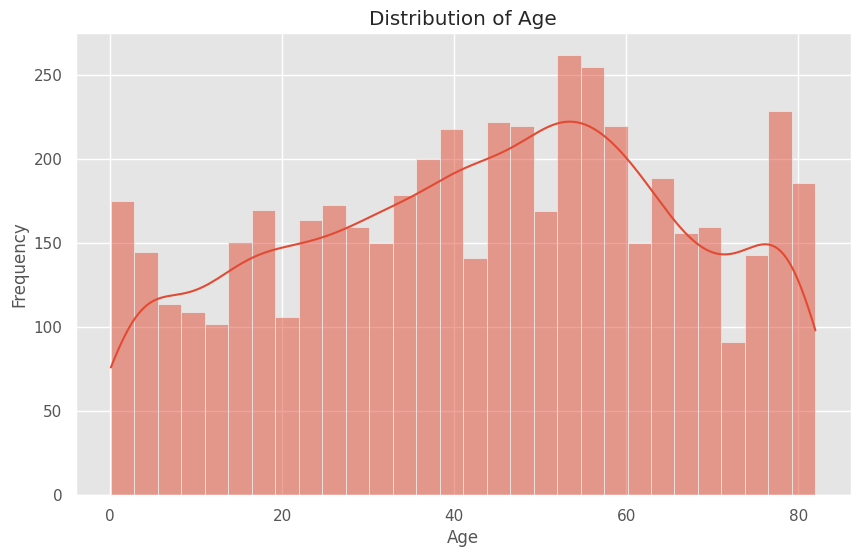

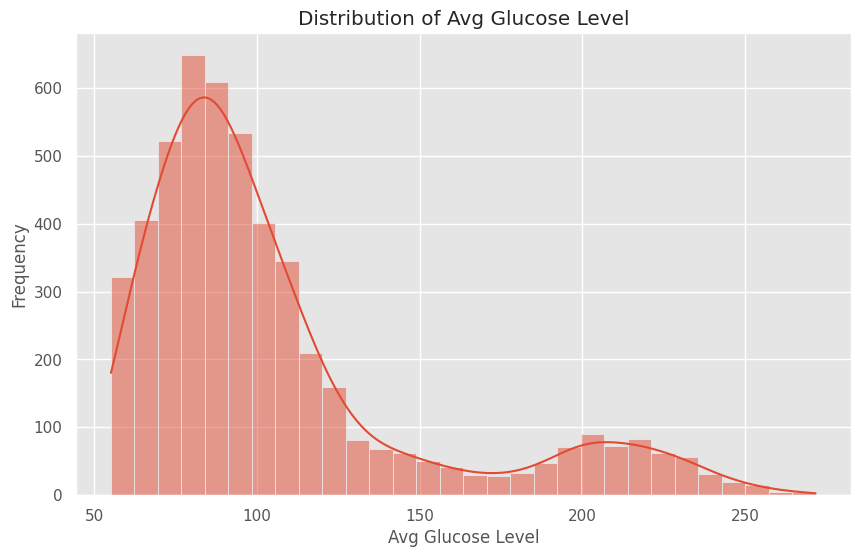

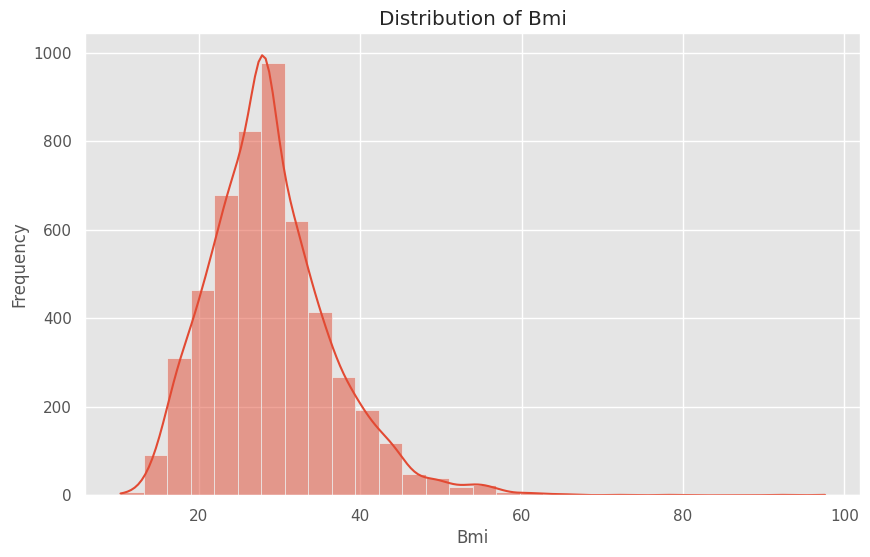

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for plots
plt.style.use('ggplot')

# 1. Identify continuous numerical features
continuous_numerical_features = ['age', 'avg_glucose_level', 'bmi']

print("Generating Histograms for Numerical Features...")

# 2. Create histograms for each continuous numerical feature
for col in continuous_numerical_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.show()


We will create count plots for binary and categorical features to visualize their frequencies and distribution. Each plot will have an appropriate title and labels for clarity.


Generating Count Plots for Categorical Features...


/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


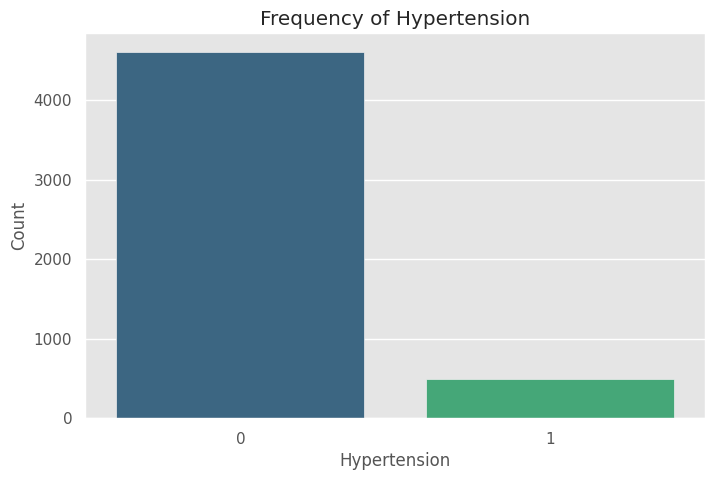

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


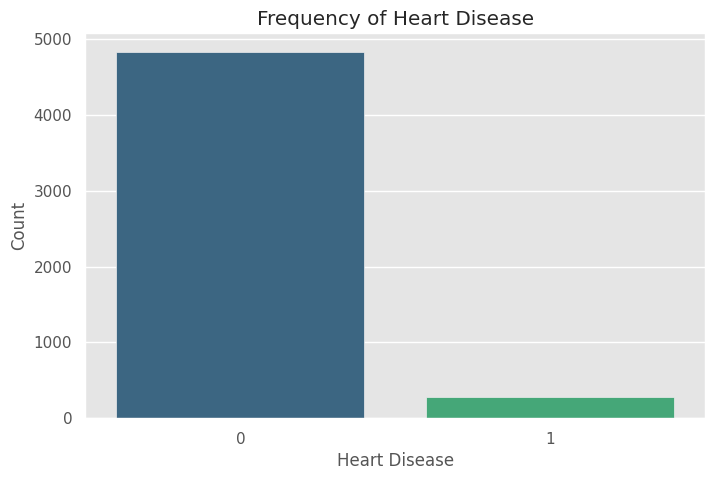

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


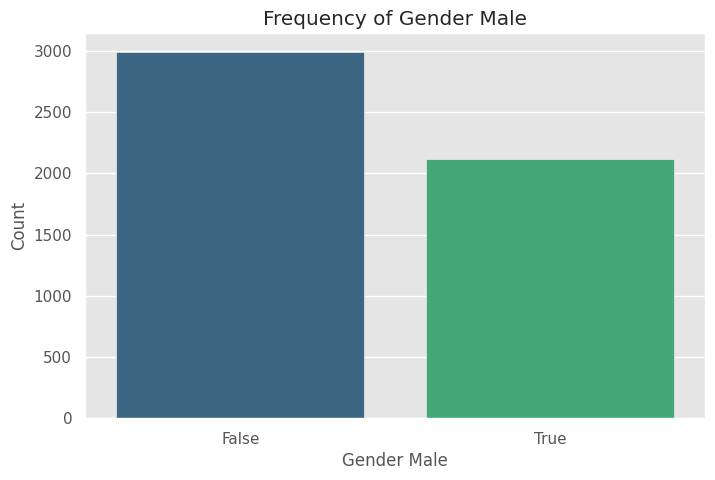

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


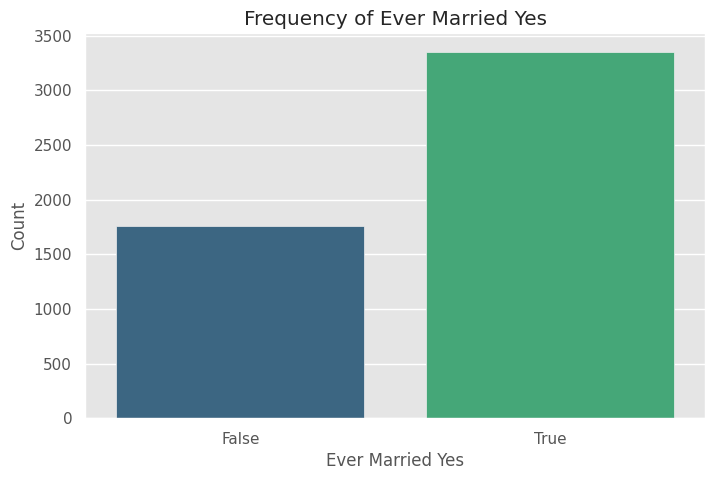

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


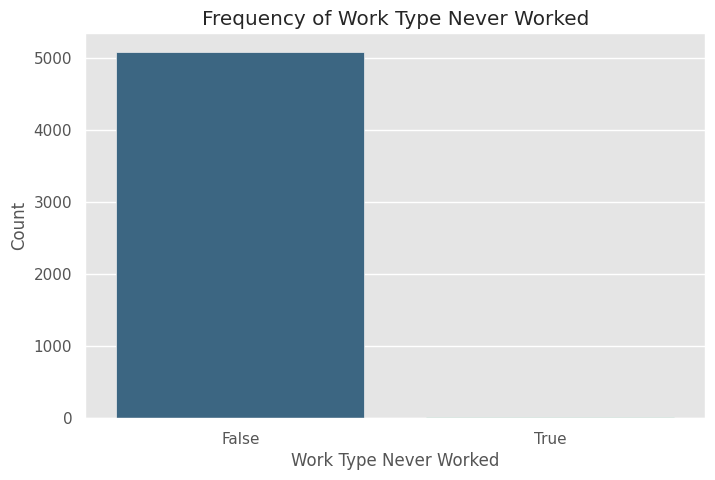

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


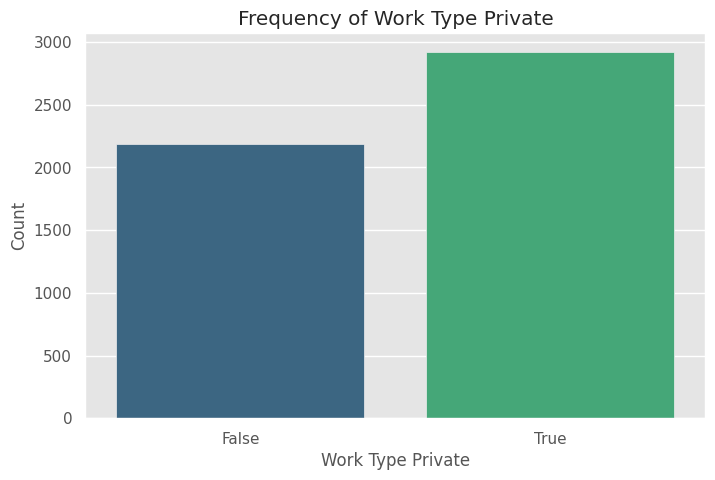

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


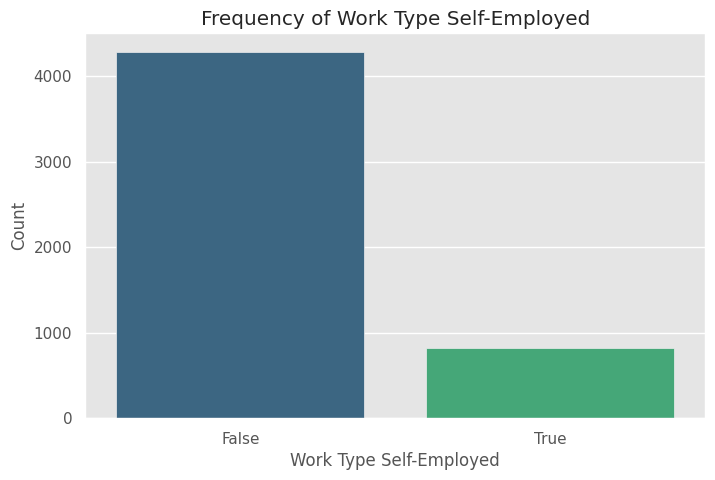

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


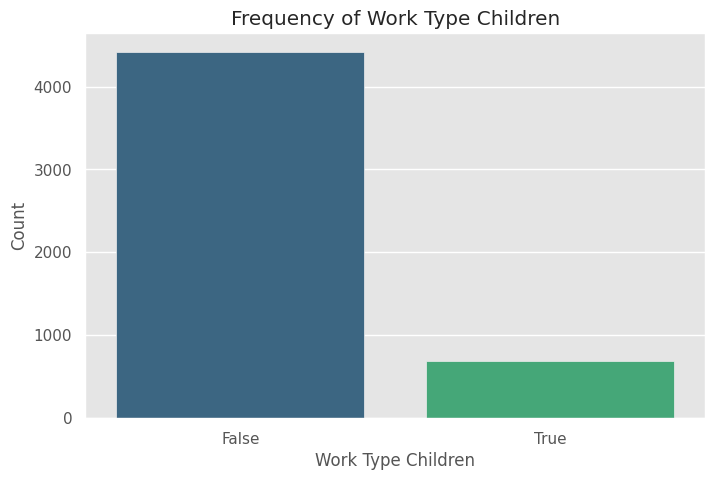

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


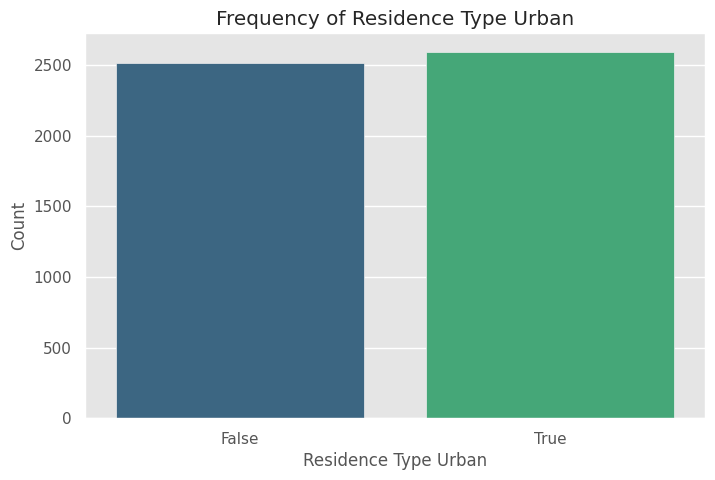

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


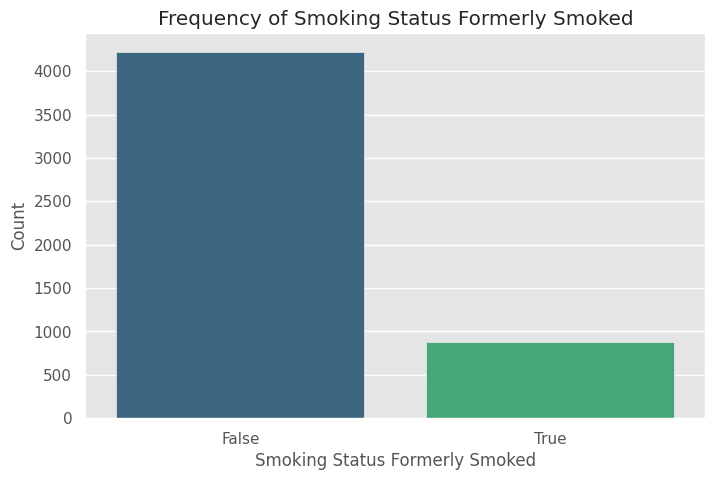

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


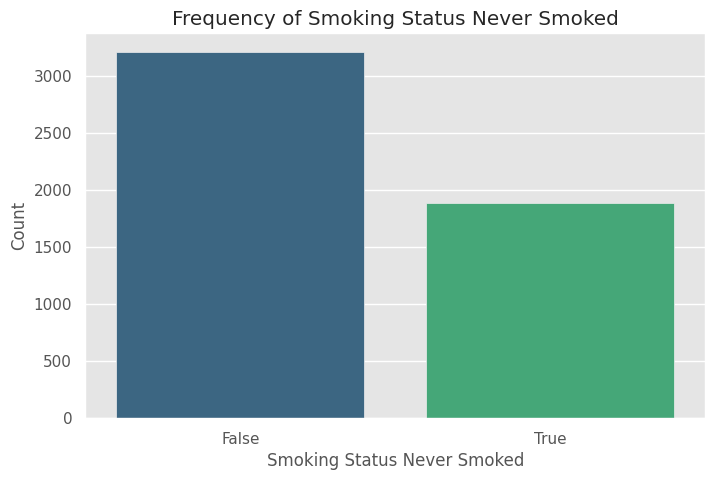

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


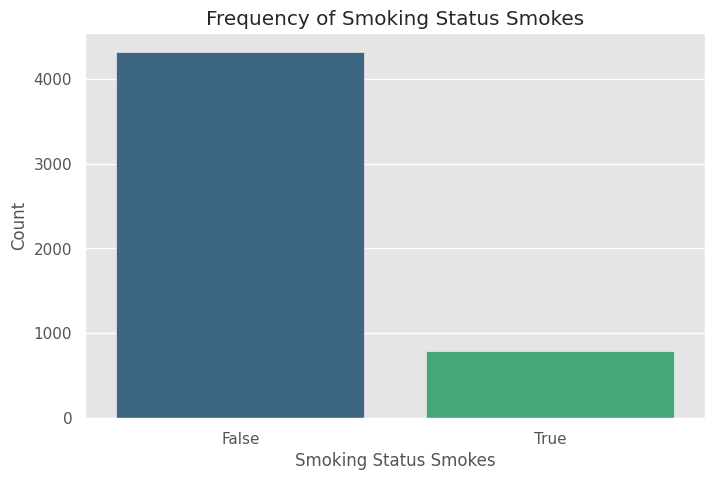

/tmp/ipykernel_221/3423833437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


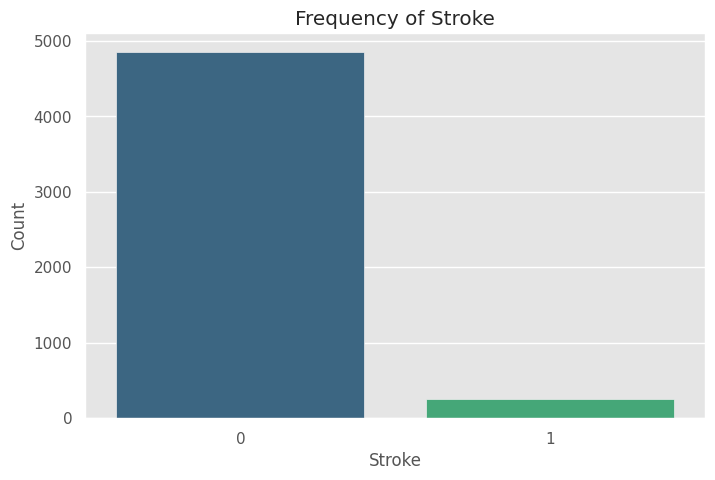

In [16]:
print("\nGenerating Count Plots for Categorical Features...")

# 3. Identify binary/categorical features (including one-hot encoded ones)
binary_categorical_features = ['hypertension', 'heart_disease', 'gender_Male', 'ever_married_Yes',
                               'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed',
                               'work_type_children', 'Residence_type_Urban',
                               'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes',
                               'stroke']

# 4. Create count plots for each binary/categorical feature
for col in binary_categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Frequency of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Count')
    plt.show()

The previous code generated a `FutureWarning`. To fix this, we'll explicitly set `hue=col` and `legend=False` in the `sns.countplot` call, as suggested.

### Bivariate Analysis

This analysis explores relationships between features and 'stroke'. We will generate box plots for numerical features and count plots for categorical features against the target variable to observe trends and correlations.

We will generate box plots for each continuous numerical feature ('age', 'avg_glucose_level', 'bmi') against the 'stroke' target variable. This will visualize their distributions for individuals with and without stroke.

/tmp/ipykernel_221/3615456185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, palette='viridis')



Generating Box Plots for Numerical Features vs. Stroke...


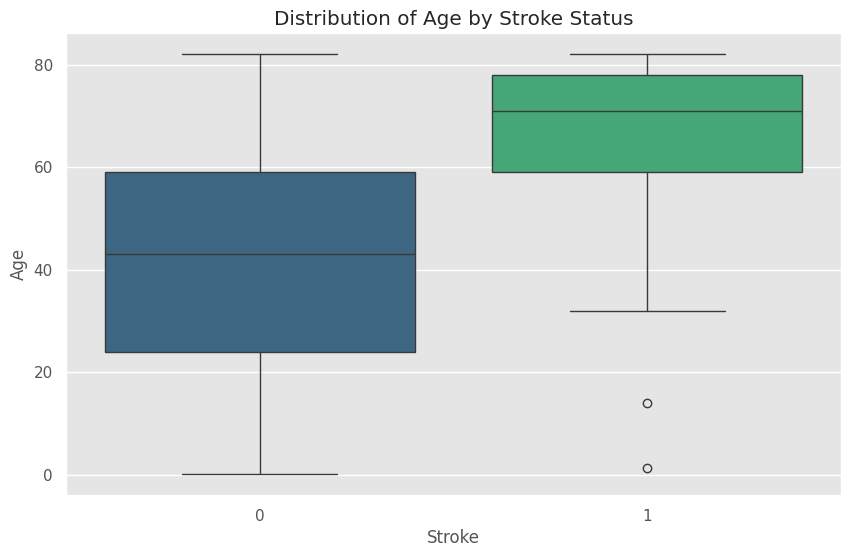

/tmp/ipykernel_221/3615456185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, palette='viridis')


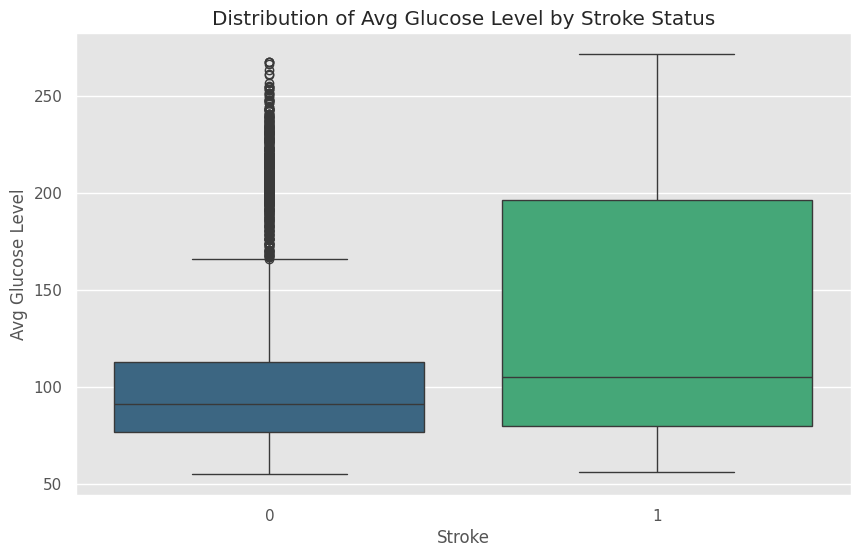

/tmp/ipykernel_221/3615456185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, palette='viridis')


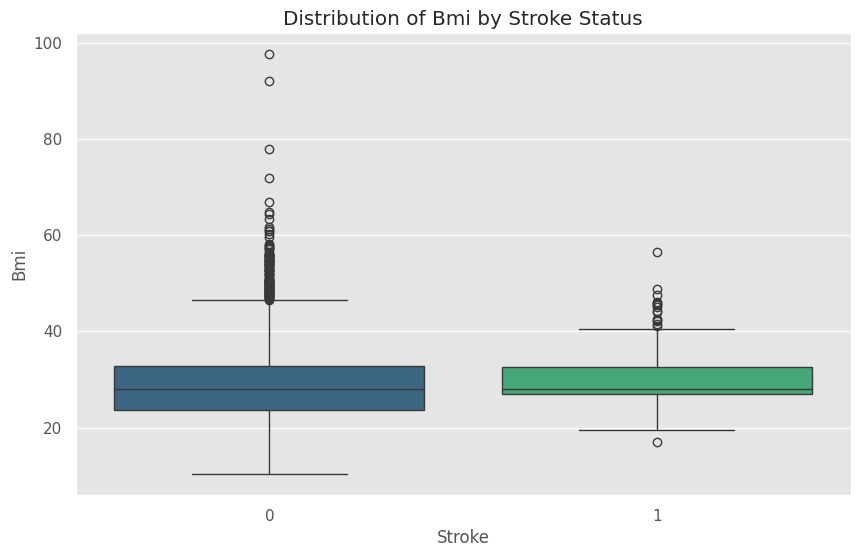

In [17]:
print("\nGenerating Box Plots for Numerical Features vs. Stroke...")

# Create box plots for each continuous numerical feature against 'stroke'
for col in continuous_numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='stroke', y=col, palette='viridis')
    plt.title(f'Distribution of {col.replace("_", " ").title()} by Stroke Status')
    plt.xlabel('Stroke')
    plt.ylabel(col.replace("_", " ").title())
    plt.show()

The previous code generated a `FutureWarning`. To address this, we'll modify the `sns.boxplot` call by setting `hue='stroke'` and `legend=False`, as suggested by the warning.

### Bivariate Analysis Insights

Age, hypertension, heart disease, and average glucose levels show strong correlations with stroke. Individuals with stroke tend to be older and have higher glucose levels, hypertension, and heart disease. Smoking status also appears to increase risk.

### Correlation Heatmap

We visualize the correlation matrix of numerical features using a heatmap. This helps identify strong positive or negative correlations among variables, providing insights into feature relationships.

To visualize feature correlations, we calculate the correlation matrix using `df.corr()`. Then, we generate a heatmap with `seaborn.heatmap()`, annotating values for clarity.

Generating Correlation Heatmap...


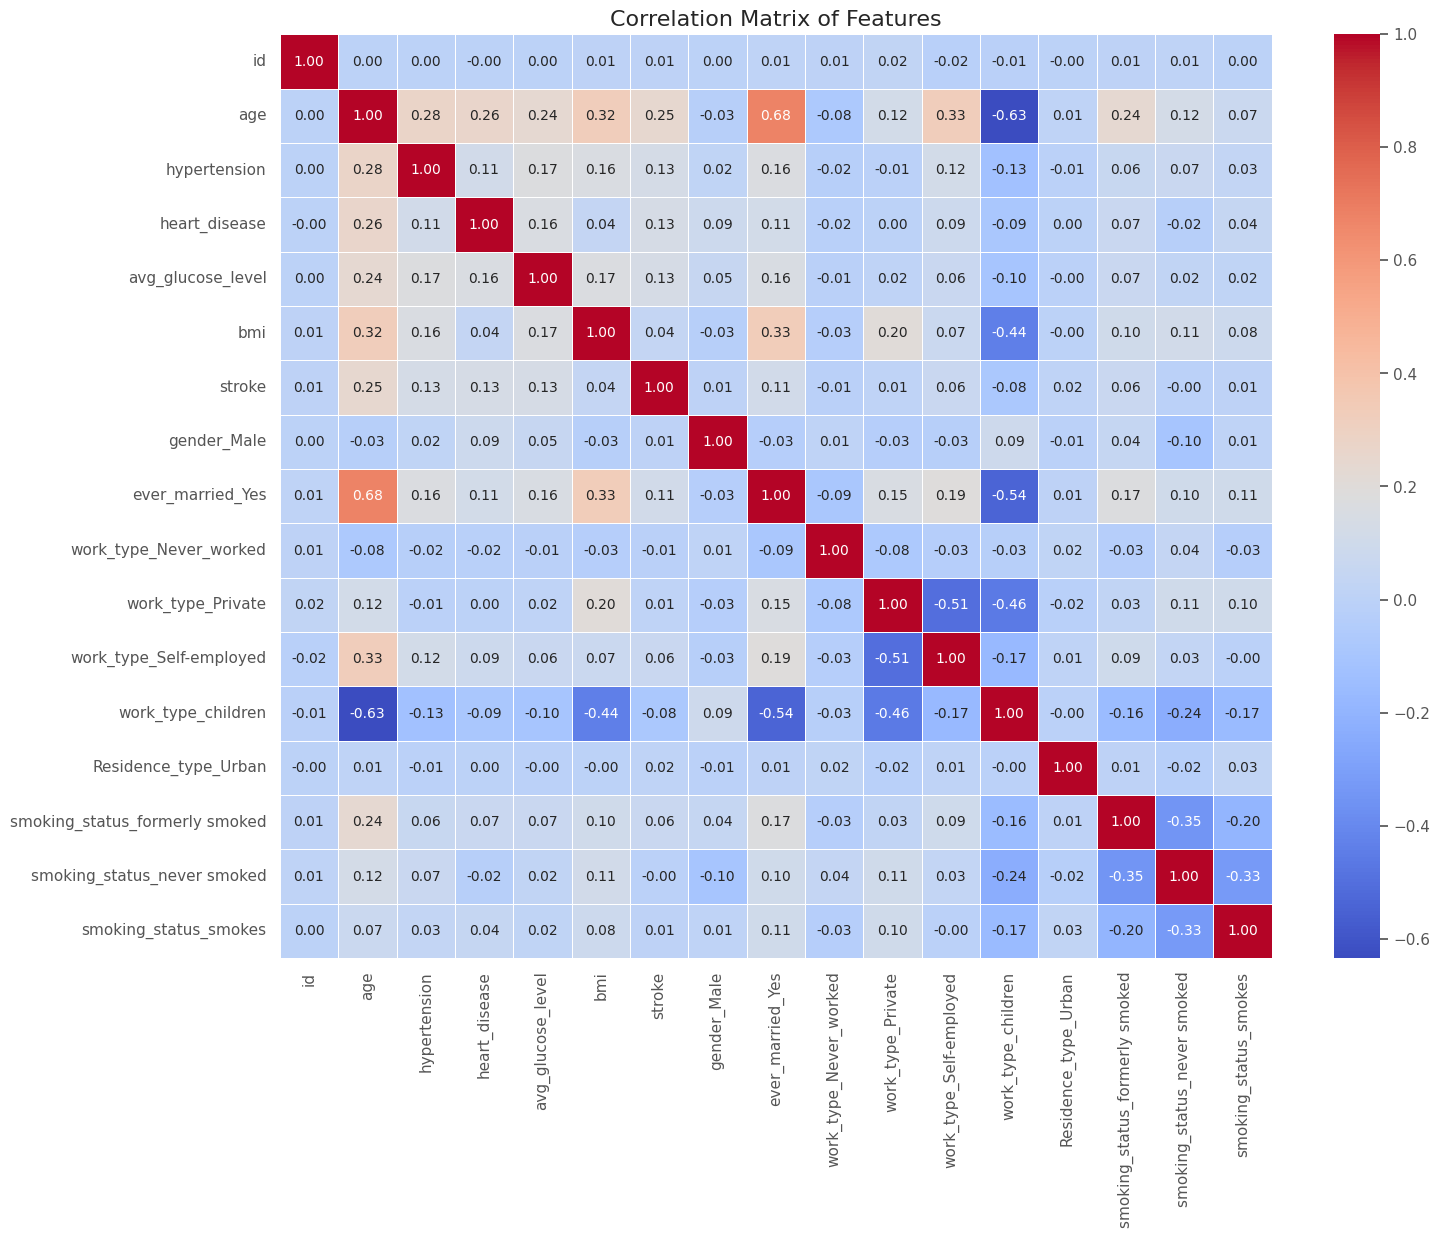

In [18]:
print("Generating Correlation Heatmap...")

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add a title to the heatmap
plt.title('Correlation Matrix of Features', fontsize=16)

# Display the plot
plt.show()

## Feature Preparation

This section separates the dataset into features (X) and the target variable (y), 'stroke'. X will contain only the preprocessed features ready for model training.

We define `y` as the 'stroke' column and `X` as the DataFrame `df` with 'id' and 'stroke' columns dropped. We then print the shapes of `X` and `y` to verify the separation.

In [19]:
y = df['stroke']
X = df.drop(columns=['id', 'stroke'])

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (5109, 15)
Shape of y: (5109,)


## Train-Test Split

We split the preprocessed data into training (80%) and testing (20%) sets. This ensures the model is evaluated on unseen data, providing an unbiased assessment of its performance.

We will use `train_test_split` from `sklearn.model_selection` to split `X` and `y`. We set `test_size=0.20`, `random_state=42` for reproducibility, and `stratify=y` to maintain class distribution. The shapes of the resulting sets will be printed.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4087, 15)
Shape of X_test: (1022, 15)
Shape of y_train: (4087,)
Shape of y_test: (1022,)


## Model Training

We initialize and train a Logistic Regression model on the training data. This model is chosen for its simplicity and interpretability in binary classification tasks.

We will initialize the `LogisticRegression` model, setting `class_weight='balanced'` to handle class imbalance and `random_state=42` for reproducibility. Then, we will fit the model using our training data (`X_train`, `y_train`).

In [21]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with class_weight='balanced' for imbalance and random_state for reproducibility
model = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear', max_iter=1000)

# Train the model on the training data
model.fit(X_train, y_train)

print("Logistic Regression model initialized and trained successfully.")

Logistic Regression model initialized and trained successfully.


## Model Evaluation

We evaluate the trained Logistic Regression model's performance on the test set. Key metrics like accuracy score and confusion matrix will be calculated and interpreted to understand the model's effectiveness.

To evaluate our model's performance, we first generate predictions on the test set (`X_test`) using the trained Logistic Regression model. These predictions, `y_pred`, will then be compared against the true labels.

In [22]:
y_pred = model.predict(X_test)
print("Predictions on the test set generated.")

Predictions on the test set generated.


Now, we will calculate and print the accuracy score and the confusion matrix. These metrics are essential for understanding how well our model performed on the unseen test data.

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy Score: 0.7319

Confusion Matrix:
[[708 264]
 [ 10  40]]


### Evaluation Metrics Insights

Our model achieved an accuracy of 73.19%. The confusion matrix showed 708 true negatives, 264 false positives, 10 false negatives, and 40 true positives. While accuracy is decent, the high number of false positives highlights a trade-off, though the low false negatives are critical for medical predictions.

## Model Interpretation

This section interprets the Logistic Regression model's coefficients to understand which features most influence stroke risk. Positive coefficients indicate increased risk, while negative coefficients suggest decreased risk.

To interpret the model, we extract the coefficients and intercept, mapping them to feature names using a Pandas Series. We then sort these coefficients by absolute value to identify the most influential features.

In [ ]:
import pandas as pd

# Extract coefficients and intercept
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Create a Pandas Series to map coefficients to feature names
feature_coefficients = pd.Series(coefficients, index=X.columns)

# Sort coefficients by their absolute values to identify the most influential features
sorted_coefficients = feature_coefficients.abs().sort_values(ascending=False)

# Get the actual coefficients in the sorted order
sorted_coefficients_actual = feature_coefficients[sorted_coefficients.index]

print(f"Model Intercept: {intercept:.4f}")
print("\nSorted Coefficients (by absolute value):")
print(sorted_coefficients_actual)

Model Intercept: -5.0728

Sorted Coefficients (by absolute value):
hypertension                      0.641479
work_type_children                0.605914
smoking_status_never smoked      -0.264642
smoking_status_smokes             0.247364
work_type_Self-employed          -0.230180
ever_married_Yes                 -0.208904
work_type_Never_worked           -0.181593
heart_disease                     0.163676
Residence_type_Urban              0.156743
gender_Male                      -0.137836
age                               0.080381
smoking_status_formerly smoked    0.070689
work_type_Private                -0.017737
avg_glucose_level                 0.004649
bmi                               0.001211
dtype: float64


## Conclusion

This project developed a Logistic Regression model to predict stroke risk. We identified key risk factors through EDA, preprocessed data, and trained a model achieving 73.19% accuracy. The model prioritizes minimizing false negatives, crucial for medical applications.